# Wstępna analiza danych alternatywnych i zmiennych objaśniających

Notebook przygotowuje eksploracyjną analizę cech dla aktualnego eksperymentu three-class opartego na pliku `stock_panel_nine_tickers_session_aligned_full_history_rich_price_adjusted_google_score_raw.csv`.

Główny nacisk jest położony na pytanie badawcze projektu: czy dane alternatywne z Google Trends, GDELT i Reddita są powiązane z przyszłym jednodniowym zwrotem akcji albo z klasą celu. Cechy cenowe są używane głównie jako punkt odniesienia, a nie jako główny przedmiot analizy korelacyjnej.

Analiza jest wykonywana na zbiorze uczącym, a nie na zbiorach walidacyjnym i testowym. Dzięki temu tabele i wykresy mogą być wykorzystane w pracy bez podglądania danych testowych podczas interpretacji cech.


In [49]:
from __future__ import annotations

from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 260)
pd.set_option("display.float_format", lambda value: f"{value:.4f}")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 7)
plt.rcParams["font.family"] = "DejaVu Sans"


## Konfiguracja projektu

Wczytywana jest ta sama konfiguracja, która jest używana w notebookach modelowych. Oznacza to ten sam plik danych, to samo wykluczenie `NFLX`, ten sam próg neutralności i ten sam podział czasowy.


In [50]:
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "data" / "datasets").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

import sys

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebook_utils.experiment_config import build_default_config
from notebook_utils.feature_set_grid_builder import FeatureFrameBuilder, FeatureSetGridBuilder
from notebook_utils.split_utils import make_split_dates, subset_by_dates

CONFIG = build_default_config(PROJECT_ROOT)
CLASS_LABELS = {0: "down", 1: "neutral", 2: "up"}
CLASS_VALUES = tuple(CLASS_LABELS)

feature_grid = FeatureSetGridBuilder.build(
    max_features_per_model=CONFIG["max_features_per_model"],
)

CONFIG


{'dataset_path': WindowsPath('C:/Users/user/OneDrive/Documents/magisterka/praca magisterska/code/data/datasets/stock_panel_nine_tickers_session_aligned_full_history_rich_price_adjusted_google_score_raw.csv'),
 'excluded_tickers': ['NFLX'],
 'neutral_band': 0.005,
 'test_size': 0.25,
 'validation_fraction_within_pretest': 0.25,
 'min_validation_dates': 20,
 'gap_days': 1,
 'random_state': 42,
 'selection_metric': 'balanced_accuracy',
 'primary_validation_metric': 'balanced_accuracy',
 'walk_forward_folds': 4,
 'walk_forward_validation_dates': 80,
 'walk_forward_min_train_dates': 252,
 'max_features_per_model': 14,
 'early_stopping_fraction': 0.2,
 'min_early_stopping_dates': 40,
 'min_fit_dates': 120}

## Wczytanie danych i odtworzenie podziału

Poniższa komórka odtwarza ramkę cech w taki sam sposób jak notebooki modelowe. Następnie wyznacza podział na zbiór uczący, walidacyjny i testowy. Dalsza analiza cech jest prowadzona na zbiorze uczącym (`train_df`).


In [51]:
raw_df = pd.read_csv(CONFIG["dataset_path"], parse_dates=["date"])
raw_df = raw_df[~raw_df["ticker"].isin(CONFIG["excluded_tickers"])].copy()
raw_df = raw_df.sort_values(["ticker", "date"]).reset_index(drop=True)

feature_df = FeatureFrameBuilder.build_feature_frame(
    raw_df,
    neutral_band=CONFIG["neutral_band"],
)

train_dates, validation_dates, test_dates = make_split_dates(
    feature_df,
    test_size=CONFIG["test_size"],
    validation_fraction_within_pretest=CONFIG["validation_fraction_within_pretest"],
    min_validation_dates=CONFIG["min_validation_dates"],
    gap_days=CONFIG["gap_days"],
)

split_date_map = {
    "train": train_dates,
    "validation": validation_dates,
    "test": test_dates,
}
feature_df["split"] = "gap"
for split_name, split_dates in split_date_map.items():
    feature_df.loc[feature_df["date"].isin(split_dates), "split"] = split_name

modeled_df = feature_df[feature_df["target"].isin(CLASS_VALUES)].copy()
modeled_df["target"] = modeled_df["target"].astype(int)
modeled_df["target_label"] = modeled_df["target"].map(CLASS_LABELS)

train_df = subset_by_dates(modeled_df, train_dates)
validation_df = subset_by_dates(modeled_df, validation_dates)
test_df = subset_by_dates(modeled_df, test_dates)

# Ta zmienna jest definiowana względem mediany ze zbioru uczącego, tak jak w modelach.
train_df, _ = FeatureFrameBuilder.add_google_trends_train_median_feature(train_df, train_df)

split_summary_rows = []
for split_name in ["train", "validation", "test"]:
    all_split_df = feature_df[feature_df["split"].eq(split_name)]
    modeled_split_df = modeled_df[modeled_df["split"].eq(split_name)]
    class_counts = modeled_split_df["target_label"].value_counts()
    split_summary_rows.append(
        {
            "split": split_name,
            "session_rows": len(all_split_df),
            "modeled_rows": len(modeled_split_df),
            "session_dates": all_split_df["date"].nunique(),
            "modeled_dates": modeled_split_df["date"].nunique(),
            "date_min": all_split_df["date"].min(),
            "date_max": all_split_df["date"].max(),
            "down": int(class_counts.get("down", 0)),
            "neutral": int(class_counts.get("neutral", 0)),
            "up": int(class_counts.get("up", 0)),
        }
    )

split_summary_df = pd.DataFrame(split_summary_rows)
split_summary_df


,split,session_rows,modeled_rows,session_dates,modeled_dates,date_min,date_max,down,neutral,up
0,train,5632,5632,704,704,2021-01-04,2023-10-19,2177,1175,2280
1,validation,1880,1880,235,235,2023-10-23,2024-09-27,615,456,809
2,test,2512,2504,314,313,2024-10-01,2025-12-31,893,618,993


## Zakres analizowanych cech

Notebook rozdziela cechy na dwie grupy. Pierwsza grupa to cechy alternatywne, czyli Google Trends, GDELT i Reddit. To one są głównym przedmiotem analizy. Druga grupa to krótkie zmienne rynkowe używane tylko jako punkt odniesienia.


In [52]:
def unique_in_order(values: list[str]) -> list[str]:
    return list(dict.fromkeys(values))


def option_columns(options: dict[str, list[str]]) -> list[str]:
    columns: list[str] = []
    for option_values in options.values():
        columns.extend(option_values)
    return unique_in_order(columns)


google_features = unique_in_order(
    option_columns(feature_grid.google_trends_feature_options)
    + option_columns(feature_grid.google_score_attention_feature_options)
)
gdelt_features = unique_in_order(
    option_columns(feature_grid.gdelt_feature_options)
    + option_columns(feature_grid.gdelt_sentiment_feature_options)
    + option_columns(feature_grid.gdelt_attention_feature_options)
)
reddit_features = unique_in_order(
    option_columns(feature_grid.reddit_feature_options)
    + option_columns(feature_grid.reddit_attention_feature_options)
)

alternative_feature_groups = {
    "Google Trends": google_features,
    "GDELT": gdelt_features,
    "Reddit": reddit_features,
}

market_reference_features = [
    "future_return_1d",
    "return_1d",
    "return_5d",
    "rolling_volatility_20d",
    "volume_zscore_20d",
]

alternative_feature_columns = unique_in_order(
    [column for columns in alternative_feature_groups.values() for column in columns]
)
available_alternative_features = [
    column for column in alternative_feature_columns if column in train_df.columns
]
available_market_reference_features = [
    column for column in market_reference_features if column in train_df.columns
]

tested_feature_columns = unique_in_order(
    [column for features in feature_grid.feature_sets.values() for column in features]
)
available_tested_feature_columns = [column for column in tested_feature_columns if column in train_df.columns]


def feature_source(feature: str) -> str:
    if feature.startswith("google_"):
        return "Google Trends"
    if feature.startswith("gdelt_"):
        return "GDELT"
    if feature.startswith("reddit_"):
        return "Reddit"
    return "Other"


def feature_role(feature: str) -> str:
    if "sentiment" in feature or "vader" in feature:
        return "sentiment"
    if "article" in feature or "comment_count" in feature or "trends" in feature or "above" in feature:
        return "attention"
    if "missing" in feature:
        return "missing flag"
    return "other"

group_summary_rows = []
for group_name, columns in alternative_feature_groups.items():
    available_columns = [column for column in columns if column in train_df.columns]
    group_summary_rows.append(
        {
            "feature_group": group_name,
            "defined_columns": len(columns),
            "available_columns": len(available_columns),
            "columns": ", ".join(available_columns),
        }
    )

feature_group_summary_df = pd.DataFrame(group_summary_rows)

candidate_feature_sets_df = pd.DataFrame(feature_grid.feature_set_metadata.values()).sort_values(
    ["feature_family", "n_features", "feature_set"]
).reset_index(drop=True)

feature_family_summary_df = (
    candidate_feature_sets_df
    .groupby("feature_family", as_index=False)
    .agg(
        feature_sets=("feature_set", "count"),
        min_features=("n_features", "min"),
        max_features=("n_features", "max"),
    )
    .sort_values(["feature_family"])
    .reset_index(drop=True)
)

print(f"Liczba wariantów zestawów cech: {len(candidate_feature_sets_df)}")
display(feature_group_summary_df)
display(feature_family_summary_df)


Liczba wariantów zestawów cech: 80


,feature_group,defined_columns,available_columns,columns
0,Google Trends,9,9,"google_trends_above_ticker_train_median, googl..."
1,GDELT,16,16,"gdelt_sentiment_zscore_10d, gdelt_article_coun..."
2,Reddit,16,16,"reddit_sentiment_zscore_6d, reddit_comment_cou..."


,feature_family,feature_sets,min_features,max_features
0,price + volume,7,9,9
1,price + volume + GDELT,7,11,12
2,price + volume + GDELT + Google,2,12,12
3,price + volume + GDELT + Reddit,4,13,13
4,price + volume + GDELT + Reddit attention,2,11,11
5,price + volume + GDELT attention,6,10,12
6,price + volume + GDELT attention lags,1,12,12
7,price + volume + GDELT sentiment + Reddit + Go...,2,12,12
8,price + volume + GDELT sentiment + Reddit atte...,3,11,11
9,price + volume + GDELT sentiment lags,1,12,12


## Braki danych w cechach alternatywnych

Tabela pokazuje odsetek braków danych tylko dla cech alternatywnych używanych w testowanych zestawach modeli. Braki są spodziewane zwłaszcza dla zmiennych kroczących, rang i opóźnień, ponieważ na początku historii każdej spółki nie ma jeszcze wystarczającego okna obserwacji.


In [53]:
missing_summary_df = pd.DataFrame(
    {
        "feature": available_alternative_features,
        "source": [feature_source(feature) for feature in available_alternative_features],
        "role": [feature_role(feature) for feature in available_alternative_features],
        "missing_count": train_df[available_alternative_features].isna().sum().values,
        "missing_pct": train_df[available_alternative_features].isna().mean().mul(100).values,
        "mean": train_df[available_alternative_features].mean(numeric_only=True).values,
        "std": train_df[available_alternative_features].std(numeric_only=True).values,
        "median": train_df[available_alternative_features].median(numeric_only=True).values,
    }
).sort_values(["missing_pct", "source", "feature"], ascending=[False, True, True]).reset_index(drop=True)

missing_summary_df.head(40)


,feature,source,role,missing_count,missing_pct,mean,std,median
0,google_trends_zscore_60d,Google Trends,attention,250,4.4389,0.0041,1.5638,-0.1673
1,reddit_sentiment_rank_20d,Reddit,sentiment,223,3.9595,0.4945,0.3053,0.5000
2,reddit_sentiment_zscore_20d,Reddit,sentiment,223,3.9595,-0.0194,1.1542,-0.0399
3,reddit_sentiment_zscore_6d_lag3,Reddit,sentiment,190,3.3736,-0.0058,1.5811,-0.0194
4,reddit_sentiment_zscore_6d_lag2,Reddit,sentiment,182,3.2315,-0.0048,1.5812,-0.0185
5,reddit_sentiment_zscore_6d_lag1,Reddit,sentiment,174,3.0895,-0.0049,1.5802,-0.0185
6,google_trends_zscore_10d_lag3,Google Trends,attention,167,2.9652,0.0521,1.4085,0.0415
7,reddit_sentiment_zscore_6d,Reddit,sentiment,166,2.9474,-0.0055,1.5792,-0.0194
8,reddit_sentiment_zscore_6d_clip3,Reddit,sentiment,166,2.9474,-0.0101,1.2937,-0.0194
9,google_trends_zscore_10d_lag2,Google Trends,attention,159,2.8232,0.0529,1.4077,0.0431


## Dane alternatywne a przyszły jednodniowy zwrot

To jest główna analiza korelacyjna w notebooku. Sprawdzamy, czy cechy z Google Trends, GDELT i Reddita są powiązane z `future_return_1d`, czyli zwrotem z następnej sesji. To odpowiada bezpośrednio problemowi predykcji.


In [54]:
def correlation_with_outcome(
    frame: pd.DataFrame,
    features: list[str],
    outcome: str,
    *,
    min_rows: int = 30,
) -> pd.DataFrame:
    rows = []
    for feature in features:
        if feature not in frame.columns or outcome not in frame.columns:
            continue
        valid_df = frame[[feature, outcome]].dropna()
        if len(valid_df) < min_rows:
            continue
        rows.append(
            {
                "feature": feature,
                "source": feature_source(feature),
                "role": feature_role(feature),
                "spearman": valid_df[feature].corr(valid_df[outcome], method="spearman"),
                "pearson": valid_df[feature].corr(valid_df[outcome], method="pearson"),
                "valid_rows": len(valid_df),
            }
        )
    if not rows:
        return pd.DataFrame(columns=["feature", "source", "role", "spearman", "pearson", "valid_rows", "abs_spearman"])
    return (
        pd.DataFrame(rows)
        .assign(abs_spearman=lambda frame_: frame_["spearman"].abs())
        .sort_values("abs_spearman", ascending=False)
        .reset_index(drop=True)
    )

alt_future_corr_df = correlation_with_outcome(
    train_df,
    available_alternative_features,
    "future_return_1d",
)

alt_future_corr_df.head(40)


,feature,source,role,spearman,pearson,valid_rows,abs_spearman
0,reddit_sentiment_zscore_6d_lag2,Reddit,sentiment,-0.0462,-0.0480,5450,0.0462
1,google_trends_rank_20d,Google Trends,attention,0.0386,0.0341,5552,0.0386
2,google_trends_zscore_20d,Google Trends,attention,0.0372,0.0177,5490,0.0372
3,google_trends_zscore_20d_clip3,Google Trends,attention,0.0371,0.0315,5490,0.0371
4,google_trends_zscore_10d,Google Trends,attention,0.0340,0.0069,5489,0.0340
5,gdelt_article_count_log1p_zscore_6d,GDELT,attention,-0.0304,-0.0198,5608,0.0304
6,google_trends_zscore_10d_lag3,Google Trends,attention,0.0301,0.0224,5465,0.0301
7,gdelt_article_count_zscore_6d,GDELT,attention,-0.0301,-0.0206,5608,0.0301
8,gdelt_article_count_zscore_6d_clip3,GDELT,attention,-0.0301,-0.0168,5608,0.0301
9,gdelt_article_count_zscore_20d,GDELT,attention,-0.0298,-0.0231,5552,0.0298


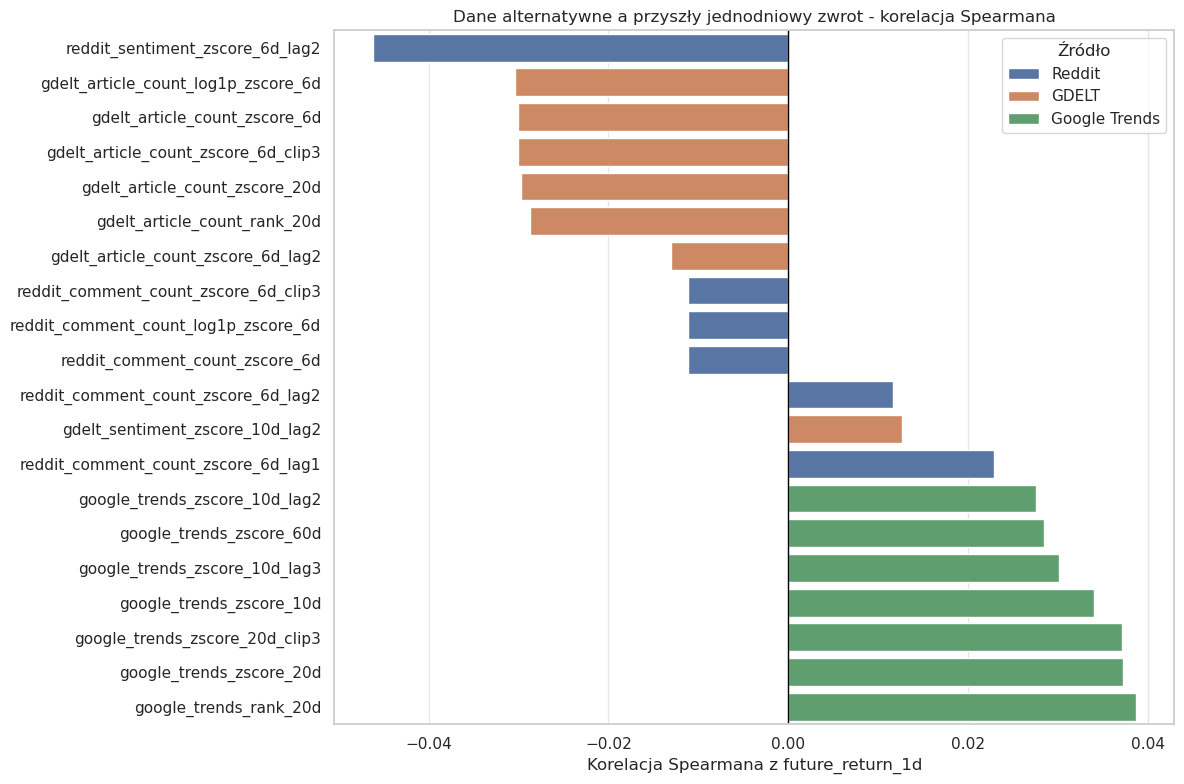

In [55]:
top_alt_future_corr_df = alt_future_corr_df.head(20).sort_values("spearman")

plt.figure(figsize=(12, 8))
sns.barplot(
    data=top_alt_future_corr_df,
    x="spearman",
    y="feature",
    hue="source",
    dodge=False,
)
plt.axvline(0, color="black", linewidth=1)
plt.title("Dane alternatywne a przyszły jednodniowy zwrot - korelacja Spearmana")
plt.xlabel("Korelacja Spearmana z future_return_1d")
plt.ylabel("")
plt.legend(title="Źródło")
plt.tight_layout()
plt.show()


In [56]:
alt_future_source_summary_df = (
    alt_future_corr_df
    .groupby("source", as_index=False)
    .agg(
        features=("feature", "count"),
        median_abs_spearman=("abs_spearman", "median"),
        mean_abs_spearman=("abs_spearman", "mean"),
        max_abs_spearman=("abs_spearman", "max"),
    )
    .sort_values("max_abs_spearman", ascending=False)
    .reset_index(drop=True)
)

best_feature_by_source_df = (
    alt_future_corr_df
    .sort_values("abs_spearman", ascending=False)
    .groupby("source", as_index=False)
    .first()[["source", "feature", "spearman", "pearson", "abs_spearman"]]
    .rename(columns={"feature": "best_feature"})
)

display(alt_future_source_summary_df)
display(best_feature_by_source_df)


,source,features,median_abs_spearman,mean_abs_spearman,max_abs_spearman
0,Reddit,16,0.0092,0.0117,0.0462
1,Google Trends,9,0.0301,0.0269,0.0386
2,GDELT,16,0.0089,0.0140,0.0304


,source,best_feature,spearman,pearson,abs_spearman
0,GDELT,gdelt_article_count_log1p_zscore_6d,-0.0304,-0.0198,0.0304
1,Google Trends,google_trends_rank_20d,0.0386,0.0341,0.0386
2,Reddit,reddit_sentiment_zscore_6d_lag2,-0.0462,-0.0480,0.0462


## Dane alternatywne a klasa celu

W tej części klasy `down`, `neutral` i `up` są traktowane jako zmienna porządkowa. Nie jest to pełna ocena predykcyjna, ale pozwala szybko sprawdzić, czy wybrane cechy alternatywne rosną albo maleją razem z klasą celu.


In [57]:
alt_target_corr_df = correlation_with_outcome(
    train_df,
    available_alternative_features,
    "target",
).rename(columns={"spearman": "spearman_with_target", "pearson": "pearson_with_target"})

alt_target_corr_df.head(40)


,feature,source,role,spearman_with_target,pearson_with_target,valid_rows,abs_spearman
0,gdelt_article_count_log1p_zscore_6d,GDELT,attention,-0.0419,-0.0402,5608,0.0419
1,gdelt_article_count_zscore_6d,GDELT,attention,-0.0415,-0.0404,5608,0.0415
2,gdelt_article_count_zscore_6d_clip3,GDELT,attention,-0.0415,-0.0381,5608,0.0415
3,gdelt_article_count_rank_20d,GDELT,attention,-0.0414,-0.0414,5552,0.0414
4,gdelt_article_count_zscore_20d,GDELT,attention,-0.0407,-0.0361,5552,0.0407
5,reddit_sentiment_zscore_6d_lag2,Reddit,sentiment,-0.0401,-0.0360,5450,0.0401
6,google_trends_rank_20d,Google Trends,attention,0.0325,0.0332,5552,0.0325
7,google_trends_zscore_10d,Google Trends,attention,0.0316,0.0167,5489,0.0316
8,google_trends_zscore_20d,Google Trends,attention,0.0300,0.0127,5490,0.0300
9,google_trends_zscore_20d_clip3,Google Trends,attention,0.0300,0.0197,5490,0.0300


In [58]:
KEY_ALT_FEATURES = [
    "google_trends_zscore_10d",
    "google_trends_rank_20d",
    "gdelt_sentiment_zscore_10d",
    "gdelt_article_count_zscore_6d",
    "reddit_sentiment_zscore_6d",
    "reddit_comment_count_zscore_6d",
]
key_alt_features = [column for column in KEY_ALT_FEATURES if column in train_df.columns]

target_summary_df = (
    train_df
    .groupby("target_label")[key_alt_features]
    .agg(["mean", "median", "std"])
    .reindex(["down", "neutral", "up"])
)

target_medians_df = train_df.groupby("target_label")[key_alt_features].median().reindex(["down", "neutral", "up"])
median_up_minus_down_df = (
    (target_medians_df.loc["up"] - target_medians_df.loc["down"])
    .rename("median_up_minus_down")
    .to_frame()
    .assign(abs_difference=lambda frame_: frame_["median_up_minus_down"].abs())
    .sort_values("abs_difference", ascending=False)
)

display(target_summary_df)
display(median_up_minus_down_df)


google_trends_zscore_10d               google_trends_rank_20d               gdelt_sentiment_zscore_10d               gdelt_article_count_zscore_6d                reddit_sentiment_zscore_6d                reddit_comment_count_zscore_6d          \
                                 mean median    std                   mean median    std                       mean median    std                          mean  median    std                       mean  median    std                           mean  median   
target_label                                                                                                                                                                                                                                                      
down                           0.0487 0.0031 1.5035                 0.4995 0.4500 0.3193                    -0.0399 0.0693 1.3571                        0.1697 -0.3732 1.5419                    -0.0010 -0.0236 1.5999                         0.2742 -0.3184   
neutral                       -0.0249 0.0603 1.2745                 0.5060 0.5000 0.3156                     0.0101 0.0672 1.2846                        0.1650 -0.3908 1.4460                    -0.0123  0.0039 1.5316                         0.2734 -0.3318   
up                             0.1008 0.0696 1.3740                 0.5231 0.5000 0.3129                    -0.0047 0.0975 1.3619                        0.0388 -0.4219 1.3492                    -0.0064 -0.0297 1.5840                         0.2274 -0.3361   

                     
                std  
target_label         
down         1.9893  
neutral      2.4864  
up           3.4197

,median_up_minus_down,abs_difference
google_trends_zscore_10d,0.0665,0.0665
google_trends_rank_20d,0.0500,0.0500
gdelt_article_count_zscore_6d,-0.0487,0.0487
gdelt_sentiment_zscore_10d,0.0282,0.0282
reddit_comment_count_zscore_6d,-0.0176,0.0176
reddit_sentiment_zscore_6d,-0.0061,0.0061


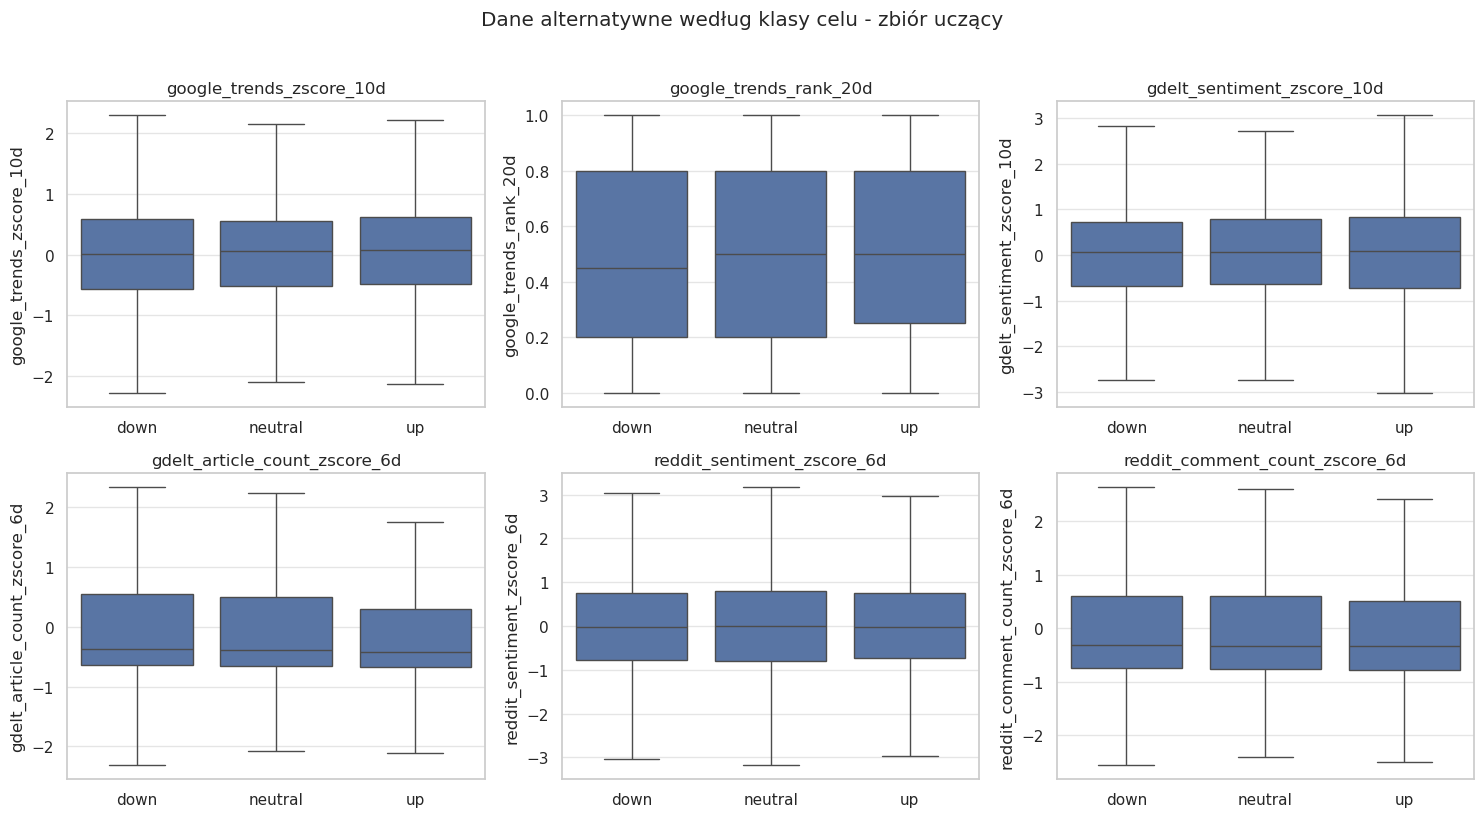

In [59]:
n_cols = 3
n_rows = int(np.ceil(len(key_alt_features) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = np.asarray(axes).reshape(-1)

for ax, feature in zip(axes, key_alt_features):
    sns.boxplot(
        data=train_df,
        x="target_label",
        y=feature,
        order=["down", "neutral", "up"],
        showfliers=False,
        ax=ax,
    )
    ax.set_title(feature)
    ax.set_xlabel("")

for ax in axes[len(key_alt_features):]:
    ax.axis("off")

plt.suptitle("Dane alternatywne według klasy celu - zbiór uczący", y=1.02)
plt.tight_layout()
plt.show()


## Opóźnienia danych alternatywnych

Wpływ danych alternatywnych nie musi być widoczny w tej samej sesji. Dlatego poniżej porównywane są korelacje wybranych zmiennych alternatywnych i ich opóźnień z przyszłym jednodniowym zwrotem.


In [60]:
lag_feature_families = {
    "Google Trends": [
        "google_trends_zscore_10d",
        "google_trends_zscore_10d_lag1",
        "google_trends_zscore_10d_lag2",
        "google_trends_zscore_10d_lag3",
    ],
    "GDELT sentiment": [
        "gdelt_sentiment_zscore_10d",
        "gdelt_sentiment_zscore_10d_lag1",
        "gdelt_sentiment_zscore_10d_lag2",
        "gdelt_sentiment_zscore_10d_lag3",
    ],
    "GDELT attention": [
        "gdelt_article_count_zscore_6d",
        "gdelt_article_count_zscore_6d_lag1",
        "gdelt_article_count_zscore_6d_lag2",
        "gdelt_article_count_zscore_6d_lag3",
    ],
    "Reddit sentiment": [
        "reddit_sentiment_zscore_6d",
        "reddit_sentiment_zscore_6d_lag1",
        "reddit_sentiment_zscore_6d_lag2",
        "reddit_sentiment_zscore_6d_lag3",
    ],
    "Reddit attention": [
        "reddit_comment_count_zscore_6d",
        "reddit_comment_count_zscore_6d_lag1",
        "reddit_comment_count_zscore_6d_lag2",
        "reddit_comment_count_zscore_6d_lag3",
    ],
}

lag_rows = []
for family, columns in lag_feature_families.items():
    for lag, feature in enumerate(columns):
        if feature not in train_df.columns:
            continue
        valid_df = train_df[[feature, "future_return_1d"]].dropna()
        if len(valid_df) < 30:
            continue
        lag_rows.append(
            {
                "family": family,
                "lag_sessions": lag,
                "feature": feature,
                "spearman_with_future_return": valid_df[feature].corr(valid_df["future_return_1d"], method="spearman"),
                "pearson_with_future_return": valid_df[feature].corr(valid_df["future_return_1d"], method="pearson"),
                "valid_rows": len(valid_df),
            }
        )

alt_lag_corr_df = pd.DataFrame(lag_rows)
alt_lag_corr_pivot_df = alt_lag_corr_df.pivot(
    index="lag_sessions",
    columns="family",
    values="spearman_with_future_return",
)

display(alt_lag_corr_df)
display(alt_lag_corr_pivot_df)


,family,lag_sessions,feature,spearman_with_future_return,pearson_with_future_return,valid_rows
0,Google Trends,0,google_trends_zscore_10d,0.0340,0.0069,5489
1,Google Trends,1,google_trends_zscore_10d_lag1,0.0038,0.0001,5481
2,Google Trends,2,google_trends_zscore_10d_lag2,0.0276,-0.0019,5473
3,Google Trends,3,google_trends_zscore_10d_lag3,0.0301,0.0224,5465
4,GDELT sentiment,0,gdelt_sentiment_zscore_10d,0.0080,0.0103,5526
5,GDELT sentiment,1,gdelt_sentiment_zscore_10d_lag1,-0.0076,0.0024,5518
6,GDELT sentiment,2,gdelt_sentiment_zscore_10d_lag2,0.0126,0.0140,5510
7,GDELT sentiment,3,gdelt_sentiment_zscore_10d_lag3,-0.0070,-0.0094,5502
8,GDELT attention,0,gdelt_article_count_zscore_6d,-0.0301,-0.0206,5608
9,GDELT attention,1,gdelt_article_count_zscore_6d_lag1,0.0098,0.0265,5600


family,GDELT attention,GDELT sentiment,Google Trends,Reddit attention,Reddit sentiment
lag_sessions,,,,,
0,-0.0301,0.0080,0.0340,-0.0111,0.0070
1,0.0098,-0.0076,0.0038,0.0229,-0.0088
2,-0.0131,0.0126,0.0276,0.0116,-0.0462
3,-0.0039,-0.0070,0.0301,-0.0047,-0.0067


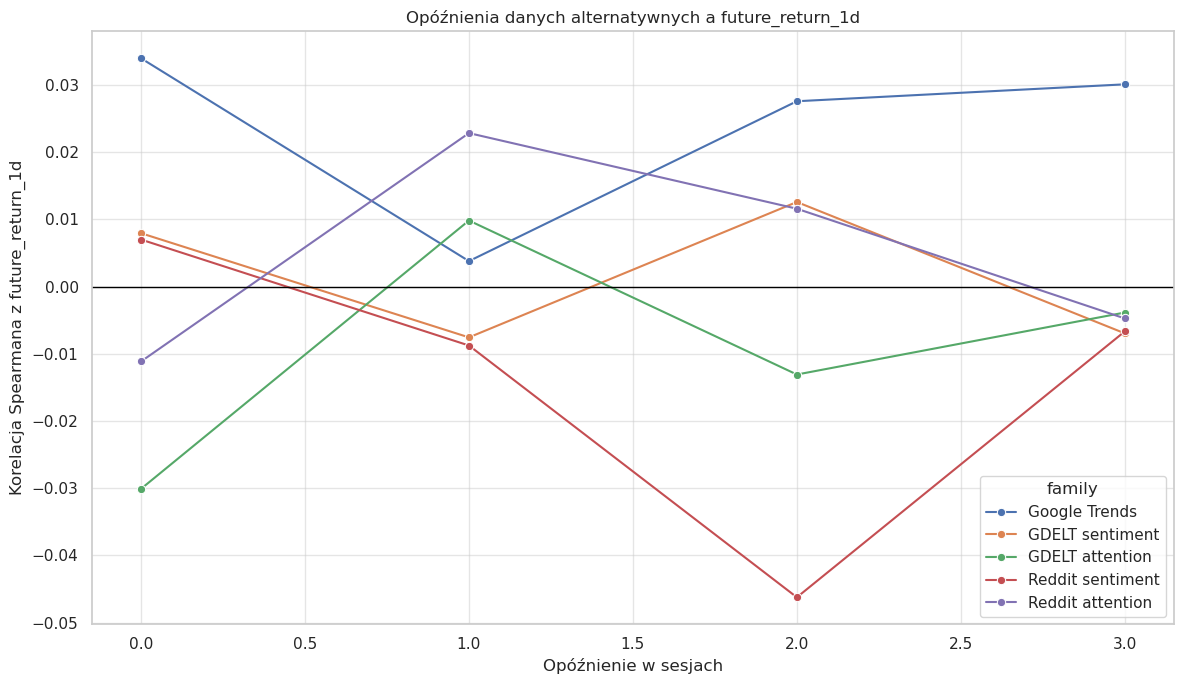

In [61]:
plt.figure(figsize=(12, 7))
sns.lineplot(
    data=alt_lag_corr_df,
    x="lag_sessions",
    y="spearman_with_future_return",
    hue="family",
    marker="o",
)
plt.axhline(0, color="black", linewidth=1)
plt.title("Opóźnienia danych alternatywnych a future_return_1d")
plt.xlabel("Opóźnienie w sesjach")
plt.ylabel("Korelacja Spearmana z future_return_1d")
plt.tight_layout()
plt.show()


## Dane alternatywne a podstawowe zmienne rynkowe

Ta część sprawdza, czy dane alternatywne są mocno powiązane z podstawowymi zmiennymi rynkowymi. Jeśli korelacje są niskie, oznacza to, że dane alternatywne nie są prostym powtórzeniem informacji zawartej w cenie lub wolumenie.


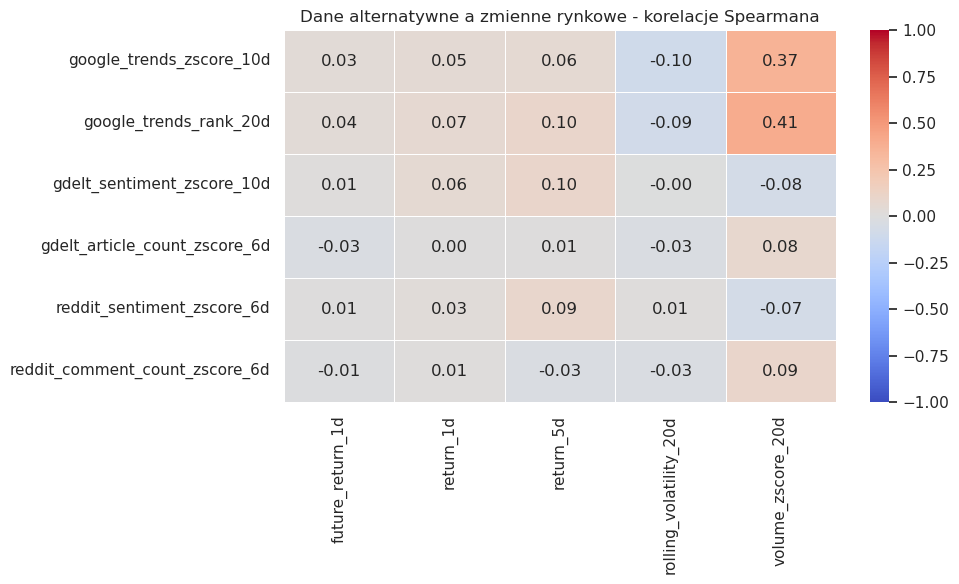

,future_return_1d,return_1d,return_5d,rolling_volatility_20d,volume_zscore_20d
google_trends_zscore_10d,0.0340,0.0487,0.0570,-0.0969,0.3663
google_trends_rank_20d,0.0386,0.0653,0.0959,-0.0885,0.4058
gdelt_sentiment_zscore_10d,0.0080,0.0557,0.0992,-0.0000,-0.0755
gdelt_article_count_zscore_6d,-0.0301,0.0020,0.0058,-0.0286,0.0842
reddit_sentiment_zscore_6d,0.0070,0.0265,0.0917,0.0097,-0.0716
reddit_comment_count_zscore_6d,-0.0111,0.0117,-0.0281,-0.0308,0.0947


In [62]:
alt_market_corr_features = key_alt_features + available_market_reference_features
alt_market_corr_features = unique_in_order([column for column in alt_market_corr_features if column in train_df.columns])

alt_market_corr_df = train_df[alt_market_corr_features].corr(method="spearman").loc[
    key_alt_features,
    available_market_reference_features,
]

plt.figure(figsize=(10, 6))
sns.heatmap(
    alt_market_corr_df,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
)
plt.title("Dane alternatywne a zmienne rynkowe - korelacje Spearmana")
plt.tight_layout()
plt.show()

alt_market_corr_df


## Autokorelacja danych alternatywnych

Autokorelacja pokazuje, czy dana zmienna jest podobna do swoich wcześniejszych wartości. Jednodniowy zwrot jest dodany tylko jako punkt odniesienia. W praktyce dane attention, takie jak liczba artykułów, komentarzy albo wyszukiwań, mogą być bardziej trwałe w czasie niż dzienne stopy zwrotu.


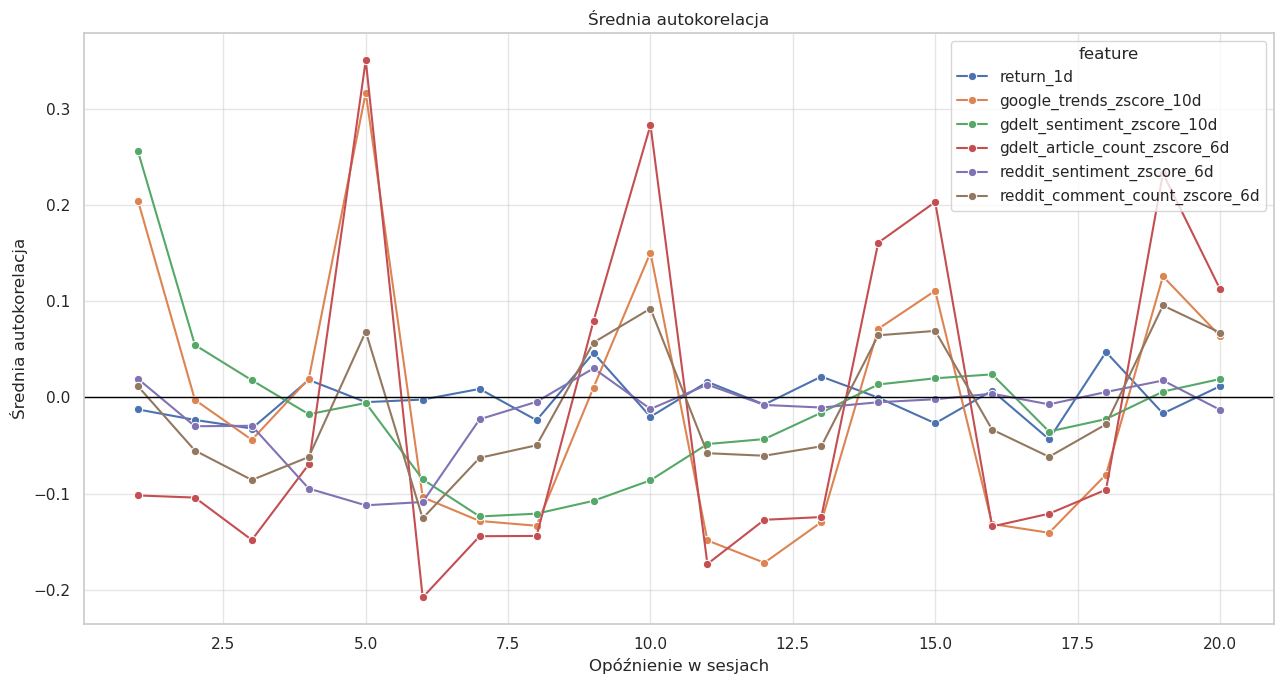

feature,gdelt_article_count_zscore_6d,gdelt_sentiment_zscore_10d,google_trends_zscore_10d,reddit_comment_count_zscore_6d,reddit_sentiment_zscore_6d,return_1d
lag,,,,,,
1,-0.1017,0.2556,0.2044,0.0116,0.0193,-0.0124
2,-0.1040,0.0545,-0.0025,-0.0551,-0.0299,-0.0233
3,-0.1480,0.0179,-0.0440,-0.0857,-0.0294,-0.0322
4,-0.0694,-0.0174,0.0195,-0.0618,-0.0946,0.0182
5,0.3502,-0.0057,0.3165,0.0684,-0.1120,-0.0049
6,-0.2076,-0.0850,-0.1036,-0.1254,-0.1086,-0.0022
7,-0.1441,-0.1236,-0.1282,-0.0627,-0.0227,0.0089
8,-0.1438,-0.1207,-0.1332,-0.0496,-0.0045,-0.0236
9,0.0794,-0.1073,0.0103,0.0571,0.0302,0.0463


In [63]:
AUTOCORR_FEATURES = [
    "return_1d",
    "google_trends_zscore_10d",
    "gdelt_sentiment_zscore_10d",
    "gdelt_article_count_zscore_6d",
    "reddit_sentiment_zscore_6d",
    "reddit_comment_count_zscore_6d",
]
autocorr_features = [column for column in AUTOCORR_FEATURES if column in train_df.columns]


def mean_autocorrelation_by_lag(
    frame: pd.DataFrame,
    feature: str,
    lags: range,
) -> list[dict]:
    rows = []
    ordered = frame.sort_values(["ticker", "date"])
    for lag in lags:
        values = []
        for _, ticker_df in ordered.groupby("ticker"):
            series = pd.to_numeric(ticker_df[feature], errors="coerce")
            if series.notna().sum() <= lag + 2:
                continue
            autocorr_value = series.autocorr(lag=lag)
            if pd.notna(autocorr_value):
                values.append(autocorr_value)
        rows.append(
            {
                "feature": feature,
                "lag": lag,
                "mean_autocorrelation": float(np.mean(values)) if values else np.nan,
                "tickers_used": len(values),
            }
        )
    return rows

autocorr_rows = []
for feature in autocorr_features:
    autocorr_rows.extend(mean_autocorrelation_by_lag(train_df, feature, range(1, 21)))

autocorr_df = pd.DataFrame(autocorr_rows)

plt.figure(figsize=(13, 7))
sns.lineplot(
    data=autocorr_df,
    x="lag",
    y="mean_autocorrelation",
    hue="feature",
    marker="o",
)
plt.axhline(0, color="black", linewidth=1)
plt.title("Średnia autokorelacja")
plt.xlabel("Opóźnienie w sesjach")
plt.ylabel("Średnia autokorelacja")
plt.tight_layout()
plt.show()

autocorr_df.pivot(index="lag", columns="feature", values="mean_autocorrelation")


## Rozkłady danych alternatywnych

Histogramy pomagają ocenić, czy cechy alternatywne mają wartości odstające, skośne rozkłady albo duże skupienie wokół typowego poziomu. To jest ważne, ponieważ dane o zainteresowaniu i aktywności często mają rzadkie skoki.


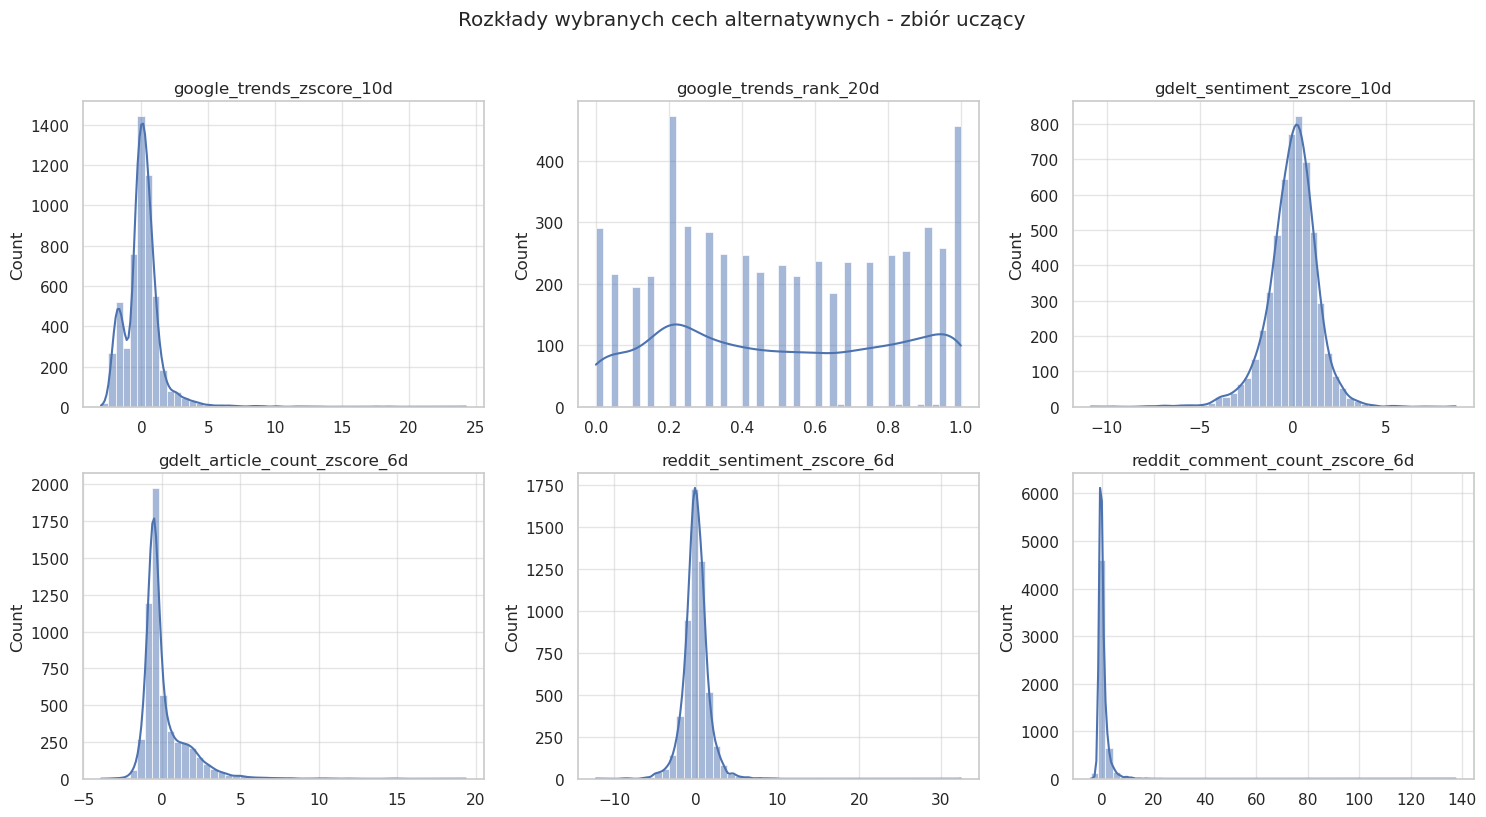

In [64]:
distribution_features = key_alt_features

n_cols = 3
n_rows = int(np.ceil(len(distribution_features) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = np.asarray(axes).reshape(-1)

for ax, feature in zip(axes, distribution_features):
    sns.histplot(train_df[feature].dropna(), bins=50, kde=True, ax=ax)
    ax.set_title(feature)
    ax.set_xlabel("")

for ax in axes[len(distribution_features):]:
    ax.axis("off")

plt.suptitle("Rozkłady wybranych cech alternatywnych - zbiór uczący", y=1.02)
plt.tight_layout()
plt.show()


## Redundancja cech alternatywnych

Ta tabela pokazuje, które pary cech alternatywnych są do siebie najbardziej podobne informacyjnie. Jest to przydatne przy interpretacji modeli, ponieważ wiele wariantów `zscore`, `rank`, `clip` i `lag` może opisywać bardzo podobne zjawisko.


In [65]:
def top_abs_correlations(
    frame: pd.DataFrame,
    columns: list[str],
    *,
    method: str = "spearman",
    top_n: int = 40,
) -> pd.DataFrame:
    corr = frame[columns].corr(method=method)
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    pairs = (
        upper
        .stack()
        .rename("correlation")
        .reset_index()
        .rename(columns={"level_0": "feature_1", "level_1": "feature_2"})
    )
    pairs["abs_correlation"] = pairs["correlation"].abs()
    pairs["source_1"] = pairs["feature_1"].map(feature_source)
    pairs["source_2"] = pairs["feature_2"].map(feature_source)
    return pairs.sort_values("abs_correlation", ascending=False).head(top_n).reset_index(drop=True)

top_alt_redundancy_df = top_abs_correlations(
    train_df,
    available_alternative_features,
    method="spearman",
    top_n=40,
)

top_alt_redundancy_df


,feature_1,feature_2,correlation,abs_correlation,source_1,source_2
0,gdelt_sentiment_zscore_10d,gdelt_sentiment_zscore_10d_clip3,1.0000,1.0000,GDELT,GDELT
1,google_trends_zscore_20d,google_trends_zscore_20d_clip3,1.0000,1.0000,Google Trends,Google Trends
2,reddit_sentiment_zscore_6d,reddit_sentiment_zscore_6d_clip3,1.0000,1.0000,Reddit,Reddit
3,gdelt_article_count_zscore_6d,gdelt_article_count_zscore_6d_clip3,1.0000,1.0000,GDELT,GDELT
4,reddit_comment_count_zscore_6d,reddit_comment_count_zscore_6d_clip3,0.9999,0.9999,Reddit,Reddit
5,gdelt_article_count_zscore_6d,gdelt_article_count_log1p_zscore_6d,0.9982,0.9982,GDELT,GDELT
6,gdelt_article_count_zscore_6d_clip3,gdelt_article_count_log1p_zscore_6d,0.9981,0.9981,GDELT,GDELT
7,reddit_comment_count_zscore_6d,reddit_comment_count_log1p_zscore_6d,0.9881,0.9881,Reddit,Reddit
8,reddit_comment_count_zscore_6d_clip3,reddit_comment_count_log1p_zscore_6d,0.9879,0.9879,Reddit,Reddit
9,reddit_sentiment_zscore_20d,reddit_sentiment_rank_20d,0.9801,0.9801,Reddit,Reddit


## Krótka kontrola cech cenowych

Cechy cenowe nie są głównym przedmiotem tej analizy, ale warto pokazać ich podstawową relację z przyszłym zwrotem jako punkt odniesienia dla danych alternatywnych.


In [66]:
PRICE_REFERENCE_FEATURES = [
    "return_1d",
    "return_5d",
    "return_20d",
    "rolling_volatility_20d",
    "intraday_return",
    "overnight_gap_return",
    "daily_high_low_range",
    "close_position_in_daily_range",
    "volume_zscore_20d",
]
price_reference_features = [column for column in PRICE_REFERENCE_FEATURES if column in train_df.columns]

price_future_corr_df = correlation_with_outcome(
    train_df,
    price_reference_features,
    "future_return_1d",
)

price_future_corr_df


,feature,source,role,spearman,pearson,valid_rows,abs_spearman
0,rolling_volatility_20d,Other,other,-0.0361,-0.0221,5464,0.0361
1,close_position_in_daily_range,Other,other,-0.0208,-0.0221,5632,0.0208
2,overnight_gap_return,Other,other,0.0190,-0.0029,5624,0.0190
3,volume_zscore_20d,Other,other,0.0119,0.0071,5552,0.0119
4,return_5d,Other,other,-0.0099,-0.0123,5592,0.0099
5,return_20d,Other,other,-0.0055,0.0110,5472,0.0055
6,intraday_return,Other,other,-0.0049,-0.0165,5632,0.0049
7,daily_high_low_range,Other,other,-0.0037,0.0098,5632,0.0037
8,return_1d,Other,other,0.0027,-0.0151,5624,0.0027


## Wskazówki do opisu w pracy

Po uruchomieniu notebooka warto opisać przede wszystkim:

- czy dane alternatywne mają widoczną korelację z przyszłym jednodniowym zwrotem,
- które źródło danych alternatywnych ma najwyższe, nawet jeśli nadal słabe, powiązanie z `future_return_1d`,
- czy opóźnienia danych alternatywnych są bardziej informacyjne niż wartości z tej samej sesji,
- czy klasy `down`, `neutral` i `up` różnią się rozkładami wybranych cech alternatywnych,
- czy dane alternatywne są mocno skorelowane z podstawowymi zmiennymi rynkowymi, czy raczej wnoszą osobną informację,
- które cechy alternatywne są redundantne i mogą powielać tę samą informację,
- czy dane attention, takie jak Google Trends, liczba artykułów GDELT i liczba komentarzy Reddita, są bardziej trwałe w czasie niż jednodniowe stopy zwrotu.

W tekście pracy warto podkreślić, że ta analiza ma charakter opisowy i została wykonana na zbiorze uczącym. Ostateczna ocena przydatności danych alternatywnych powinna wynikać z wyników modeli na walidacji i teście, a nie wyłącznie z korelacji.
